In [76]:
import numpy as np
import pandas as pd
import missingno
pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [77]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [78]:
NUTS2 = 'Thrace'
YEAR = '2024'

In [79]:
data = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

In [80]:
try:
    data.drop(columns=['Unnamed: 0'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

In [81]:
try:
    data.drop(columns=['Unnamed: 0.1'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

No column named 'Unnamed: 0'


<Axes: >

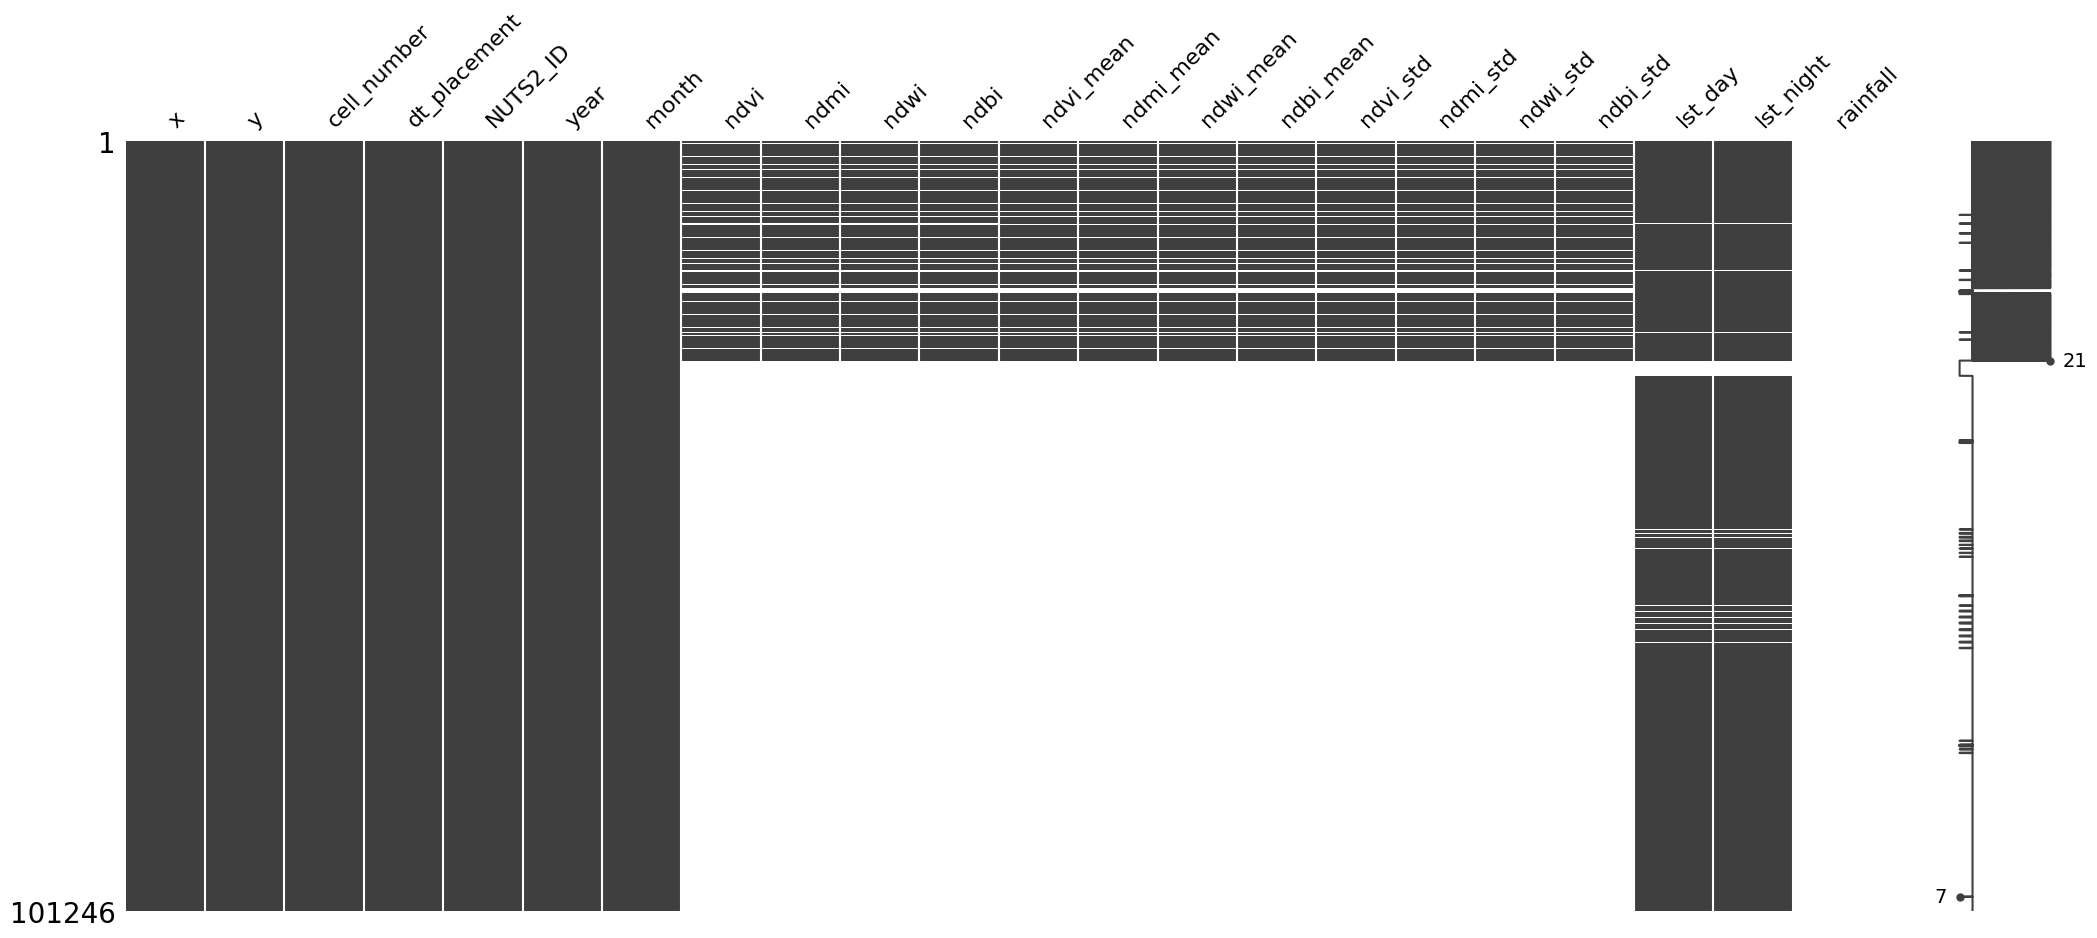

In [82]:
missingno.matrix(data)

In [83]:
data.dtypes

x               float64
y               float64
cell_number       int64
dt_placement     object
NUTS2_ID         object
year              int64
month             int64
ndvi            float64
ndmi            float64
ndwi            float64
ndbi            float64
ndvi_mean       float64
ndmi_mean       float64
ndwi_mean       float64
ndbi_mean       float64
ndvi_std        float64
ndmi_std        float64
ndwi_std        float64
ndbi_std        float64
lst_day         float64
lst_night       float64
rainfall        float64
dtype: object

<Axes: >

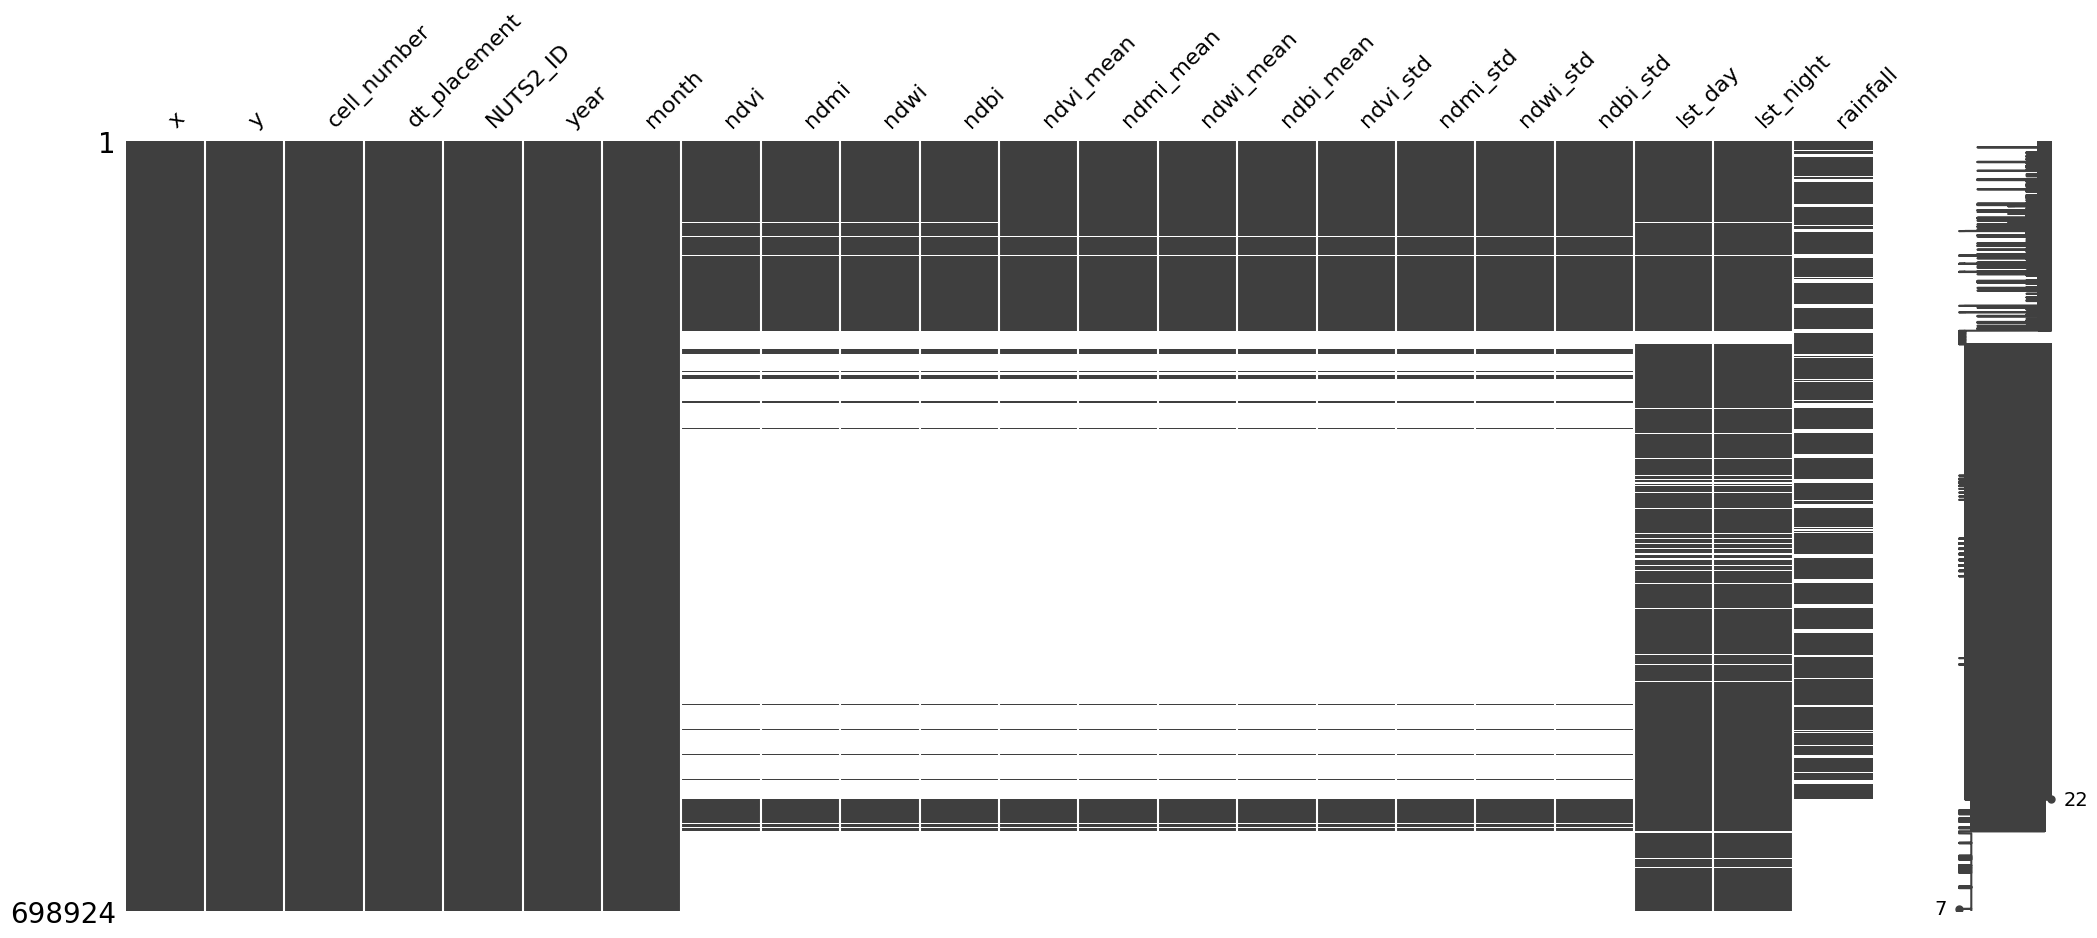

In [84]:
data_old = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled_mean_rain_shp.csv', encoding=enc)
data_old_subset = data_old[data.columns]

data = pd.concat([data_old_subset, data], axis=0, ignore_index=True)
missingno.matrix(data)

In [85]:
# data.lst_day.unique()

In [86]:
# data['lst_day'] = data['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [87]:
# data['lst_day'] = data['lst_day'].astype(float)

In [88]:
# data.drop(columns=['rainfall.1'], inplace=True)

In [89]:
data['dt_placement'] = pd.to_datetime(data['dt_placement'])

# Extract year, month, and day from the 'date' column
data['year'] = data['dt_placement'].dt.year
data['month'] = data['dt_placement'].dt.month
data['day'] = data['dt_placement'].dt.day

In [90]:
data

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day
0,23.65882,41.33542,0,2024-01-01,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,14029.0,13679.0,0.001530,1
1,23.65882,41.33542,0,2024-01-02,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,14029.0,13818.0,0.310446,2
2,23.65882,41.33542,0,2024-01-03,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,14029.0,13623.0,0.512597,3
3,23.65882,41.33542,0,2024-01-04,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,13907.0,13852.0,0.000000,4
4,23.65882,41.33542,0,2024-01-05,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,13828.0,13852.0,0.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698919,26.58397,41.49712,3261,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15529.0,14742.0,NaN,1
698920,26.60756,41.35339,3262,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15683.0,14799.0,NaN,1
698921,26.60756,41.37135,3263,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15651.0,14801.0,NaN,1
698922,26.60756,41.38932,3264,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15651.0,14759.0,NaN,1


In [91]:
data_jan = data.loc[data['month'] == 1]
data_fed = data.loc[data['month'] == 2]
data_mar = data.loc[data['month'] == 3]
data_apr = data.loc[data['month'] == 4]

In [92]:
df_mean_jan = data_jan.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_feb = data_fed.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_mar = data_mar.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_apr = data_apr.groupby(['cell_number', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()

In [93]:
df_mean_jan.rename(columns={'lst_day': 'lst_day_jan_mean', 'lst_night': 'lst_night_jan_mean'}, inplace=True)
df_mean_feb.rename(columns={'lst_day': 'lst_day_feb_mean', 'lst_night': 'lst_night_feb_mean'}, inplace=True)
df_mean_mar.rename(columns={'lst_day': 'lst_day_mar_mean', 'lst_night': 'lst_night_mar_mean'}, inplace=True)
df_mean_apr.rename(columns={'lst_day': 'lst_day_apr_mean', 'lst_night': 'lst_night_apr_mean'}, inplace=True)

In [94]:
df_mean_jan.drop(columns=['month'], inplace = True)
df_mean_feb.drop(columns=['month'], inplace = True)
df_mean_mar.drop(columns=['month'], inplace = True)
df_mean_apr.drop(columns=['month'], inplace = True)

In [95]:
df_mean = pd.merge(df_mean_jan, df_mean_feb, on=['cell_number', 'year']).merge(df_mean_mar, on=['cell_number', 'year']).merge(df_mean_apr, on=['cell_number', 'year'])

In [96]:
df_mean.loc[(df_mean['cell_number'] == 0) & (df_mean['year'] == int(YEAR))]

,cell_number,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,0,2024,13764.709677,13579.967742,14064.827586,13736.655172,14209.16129,13708.903226,14703.931034,14033.517241


In [97]:
data_mean = pd.merge(data, df_mean, on=['cell_number', 'year'])

In [98]:
data_mean

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,23.65882,41.33542,0,2024-01-01,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,14029.0,13679.0,0.001530,1,13764.709677,13579.967742,14064.827586,13736.655172,14209.161290,13708.903226,14703.931034,14033.517241
1,23.65882,41.33542,0,2024-01-02,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,14029.0,13818.0,0.310446,2,13764.709677,13579.967742,14064.827586,13736.655172,14209.161290,13708.903226,14703.931034,14033.517241
2,23.65882,41.33542,0,2024-01-03,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,14029.0,13623.0,0.512597,3,13764.709677,13579.967742,14064.827586,13736.655172,14209.161290,13708.903226,14703.931034,14033.517241
3,23.65882,41.33542,0,2024-01-04,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,13907.0,13852.0,0.000000,4,13764.709677,13579.967742,14064.827586,13736.655172,14209.161290,13708.903226,14703.931034,14033.517241
4,23.65882,41.33542,0,2024-01-05,EL51,2024,1,0.130233,0.146226,0.053554,-0.146226,0.233608,0.033984,-0.128821,-0.033984,0.086101,0.072091,0.139628,0.072091,13828.0,13852.0,0.000000,5,13764.709677,13579.967742,14064.827586,13736.655172,14209.161290,13708.903226,14703.931034,14033.517241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698919,26.58397,41.49712,3261,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15529.0,14742.0,NaN,1,14027.741935,13660.935484,14375.965517,13892.137931,14474.419355,13900.967742,14994.633333,14128.800000
698920,26.60756,41.35339,3262,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15683.0,14799.0,NaN,1,14038.903226,13690.451613,14370.758621,13948.137931,14486.419355,13923.774194,15006.100000,14171.933333
698921,26.60756,41.37135,3263,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15651.0,14801.0,NaN,1,14001.096774,13690.064516,14357.931034,13959.931034,14443.258065,13936.064516,14881.600000,14169.733333
698922,26.60756,41.38932,3264,2024-08-01,EL51,2024,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15651.0,14759.0,NaN,1,13986.225806,13692.645161,14378.206897,13931.896552,14453.451613,13918.806452,14906.800000,14143.066667


<Axes: >

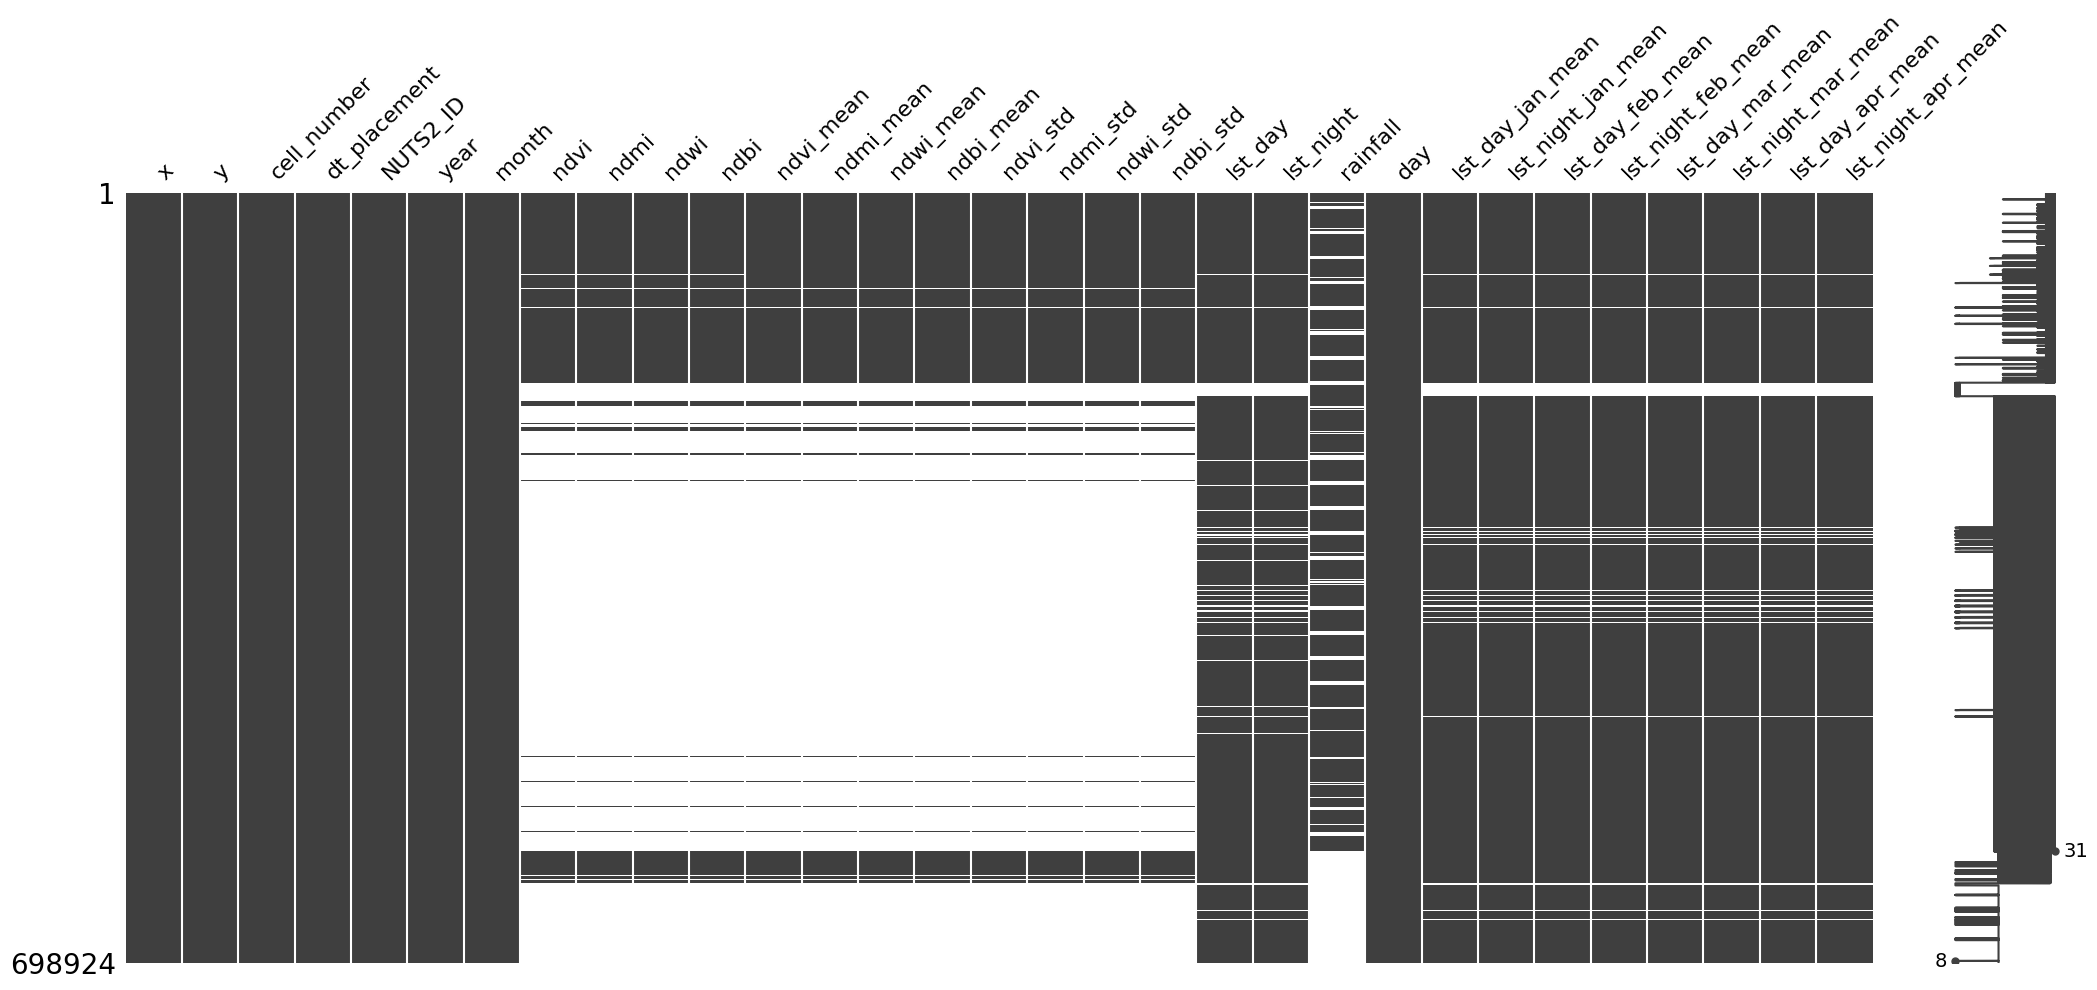

In [99]:
missingno.matrix(data_mean)

In [100]:
data_mean.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled_mean.csv', encoding='utf-8')